In [1]:
#import 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
df = pd.read_csv("../../dataset/ANN/dataset_kelulusan_mahasiswa.csv")

print(df.shape)

df.head()



(600, 12)


,Student_ID,Tugas_1,Tugas_2,Tugas_3,Quiz_1,Quiz_2,UTS,UAS,Kehadiran,Nilai_Akhir,Grade,Status
0,STD0001,60.8,62.6,68.7,53.0,73.7,35.6,50.8,84.9,50.14,D,Tidak_Lulus
1,STD0002,75.7,77.6,78.6,82.9,74.9,98.5,81.1,100.0,85.34,A,Lulus
2,STD0003,81.1,82.8,82.3,87.1,73.3,89.8,93.6,89.8,88.81,A,Lulus
3,STD0004,56.7,76.4,76.5,59.6,62.2,58.6,65.5,73.4,63.84,C,Tidak_Lulus
4,STD0005,40.6,51.3,35.9,21.2,52.4,40.2,47.6,63.7,43.30,E,Tidak_Lulus


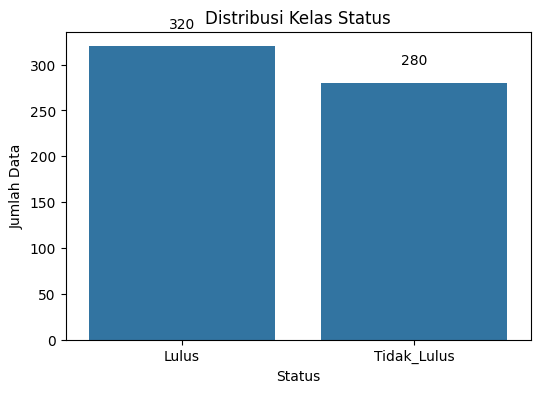

In [3]:
#cek distribusi kelas
target_counts = df["Status"].value_counts()

plt.figure(figsize=(6,4))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title("Distribusi Kelas Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Data")

# Menampilkan jumlah di atas batang
for i, value in enumerate(target_counts.values):
    ax.text(
        i,
        value + 20,
        str(value),
        ha='center'
    )

plt.show()

In [4]:
#pilih fitur
selected_features = [
    'Tugas_1',
    'Tugas_2',
    'Tugas_3',
    'UTS',
    'UAS'
]

X = df[selected_features]

y = df["Status"]

In [5]:
#encode target
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
)))

{'Lulus': np.int64(0), 'Tidak_Lulus': np.int64(1)}


In [6]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
#normalisasi
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [8]:
#model MLP
model = Sequential([
    Dense(
        64,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#early stop
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#training
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5625 - loss: 0.6728 - val_accuracy: 0.5625 - val_loss: 0.6462
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5312 - loss: 0.6438 - val_accuracy: 0.5729 - val_loss: 0.6221
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5651 - loss: 0.6215 - val_accuracy: 0.6354 - val_loss: 0.6039
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6198 - loss: 0.6001 - val_accuracy: 0.6771 - val_loss: 0.5837
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6849 - loss: 0.5773 - val_accuracy: 0.6979 - val_loss: 0.5599
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7891 - loss: 0.5475 - val_accuracy: 0.7708 - val_loss: 0.5312
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8229 - loss: 0.5104 - val_accuracy: 0.7708 - val_loss: 0.4931
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8490 - loss: 0.4666 - val_accuracy: 0.8646 - 

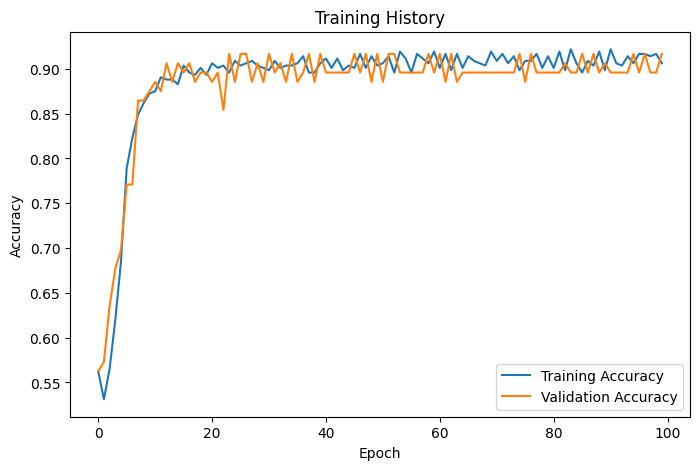

In [10]:
#grafik akurasi
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training History')
plt.legend()

plt.show()

In [11]:
#prediksi
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8500
Precision: 0.8065
Recall   : 0.8929
F1 Score : 0.8475


In [13]:
#classification report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Tidak Lulus", "Lulus"]
    )
)

              precision    recall  f1-score   support

 Tidak Lulus       0.90      0.81      0.85        64
       Lulus       0.81      0.89      0.85        56

    accuracy                           0.85       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.85      0.85      0.85       120



In [14]:
# ROC AUC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_prob
)

roc_auc = auc(
    fpr,
    tpr
)

print(f"AUC Score : {roc_auc:.4f}")

AUC Score : 0.9551


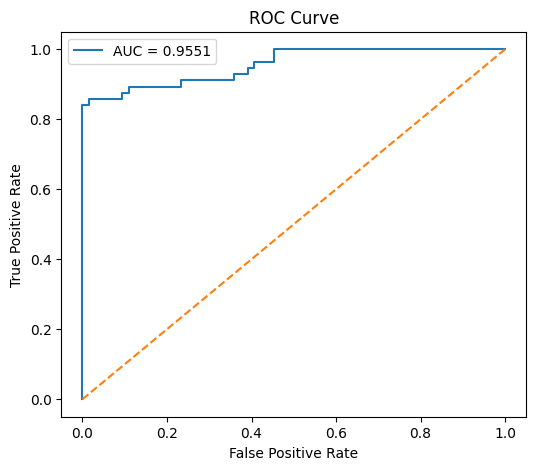

In [15]:
#plot ROC curve
plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

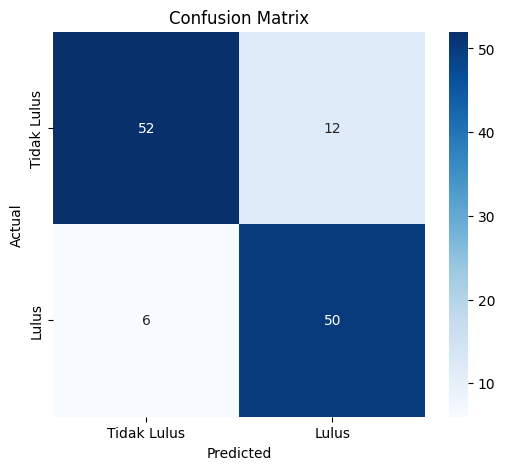

In [16]:
#confussion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Lulus', 'Lulus'],
    yticklabels=['Tidak Lulus', 'Lulus']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [26]:
#save model
model.save(
    "mlp_kelulusan_mahasiswa.keras"
) 